# 03 · Estatística Descritiva

**Objetivo deste notebook:** calcular e interpretar um conjunto completo de
métricas descritivas para as variáveis numéricas de negócio (`age`, `income`,
`purchase_count`, `total_spent`, `satisfaction_score`), identificar outliers
pelo método IQR e analisar a correlação entre variáveis — sempre traduzindo
o resultado estatístico em significado para o negócio.

Trabalhamos a partir da base já processada em `02_data_cleaning.ipynb`.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src.data_loader import load_processed_data
from src.descriptive_stats import (
    COLUNAS_NUMERICAS_PADRAO, classify_distribution_shape, compute_correlation_matrix,
    compute_descriptive_statistics, detect_outliers_iqr, recommend_outlier_action,
    summarize_segments, top_correlated_pairs,
)
from src.visualization import plot_correlation_heatmap, plot_distribution

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

df = load_processed_data()
df.shape


(5070, 18)

## Estatísticas descritivas completas

Para cada variável numérica: contagem, média, mediana, moda, desvio padrão,
variância, mínimo, máximo, amplitude, quartis (Q1/Q3), IQR, percentis
detalhados (P10-P99), assimetria (skewness), curtose (kurtosis) e coeficiente
de variação.


In [2]:
estatisticas = compute_descriptive_statistics(df, COLUNAS_NUMERICAS_PADRAO)
estatisticas.round(2).T


column,age,income,purchase_count,total_spent,satisfaction_score
count,5070.00,5.070000e+03,5070.00,5.070000e+03,5070.00
mean,38.17,6.230840e+03,11.63,3.746930e+03,3.96
median,38.00,3.366500e+03,7.00,1.652000e+03,4.00
mode,38.00,3.313500e+03,7.00,1.533000e+03,4.00
std,11.78,2.664082e+04,53.34,1.880441e+04,0.70
variance,138.83,7.097331e+08,2845.59,3.536057e+08,0.48
min,18.00,8.770000e+02,0.00,0.000000e+00,1.00
max,85.00,3.920450e+05,896.00,2.470080e+05,5.00
range,67.00,3.911680e+05,896.00,2.470080e+05,4.00
q1,30.00,2.519000e+03,5.00,1.133000e+03,3.50


### Leitura das principais métricas

- **`age`**: média e mediana próximas (~38 anos), coeficiente de variação
  moderado — distribuição relativamente homogênea, sem assimetria forte.
- **`income`** e **`total_spent`**: coeficiente de variação **muito alto**
  (centenas de %) e curtose extremamente elevada — sinal claro de outliers
  extremos puxando a variância para cima (investigado em detalhe na seção de
  outliers, abaixo).
- **`satisfaction_score`**: variável limitada à escala 1-5, com dispersão
  naturalmente baixa (CV mais baixo entre as cinco variáveis).


## Forma da distribuição (assimetria e curtose)


In [3]:
for coluna in COLUNAS_NUMERICAS_PADRAO:
    skew = estatisticas.loc[coluna, "skewness"]
    kurt = estatisticas.loc[coluna, "kurtosis"]
    forma = classify_distribution_shape(skew, kurt)
    print(f"{coluna:22s} skew={skew:8.3f} ({forma['assimetria']})")
    print(f"{'':22s} kurt={kurt:8.3f} ({forma['curtose']})\n")


age                    skew=   0.319 (aproximadamente simétrica)
                       kurt=  -0.117 (mesocúrtica (próxima da distribuição normal))

income                 skew=  10.704 (fortemente assimétrica à direita (cauda longa de valores altos))
                       kurt= 118.357 (leptocúrtica (mais concentrada, com caudas mais pesadas que a normal))

purchase_count         skew=  12.326 (fortemente assimétrica à direita (cauda longa de valores altos))
                       kurt= 158.410 (leptocúrtica (mais concentrada, com caudas mais pesadas que a normal))

total_spent            skew=  10.003 (fortemente assimétrica à direita (cauda longa de valores altos))
                       kurt= 103.532 (leptocúrtica (mais concentrada, com caudas mais pesadas que a normal))

satisfaction_score     skew=  -0.400 (aproximadamente simétrica)
                       kurt=  -0.260 (mesocúrtica (próxima da distribuição normal))



**Impacto no negócio:** variáveis fortemente assimétricas à direita com
curtose elevada (`income`, `total_spent`, `purchase_count`) indicam que a
**média** não é uma boa medida de "cliente típico" — a mediana é mais
robusta. Isso também justifica o uso de testes não paramétricos (Spearman,
Mann-Whitney) como complemento aos testes paramétricos no notebook 04, e a
escala logarítmica nos gráficos de distribuição/dispersão dessas variáveis.


## Distribuições visuais


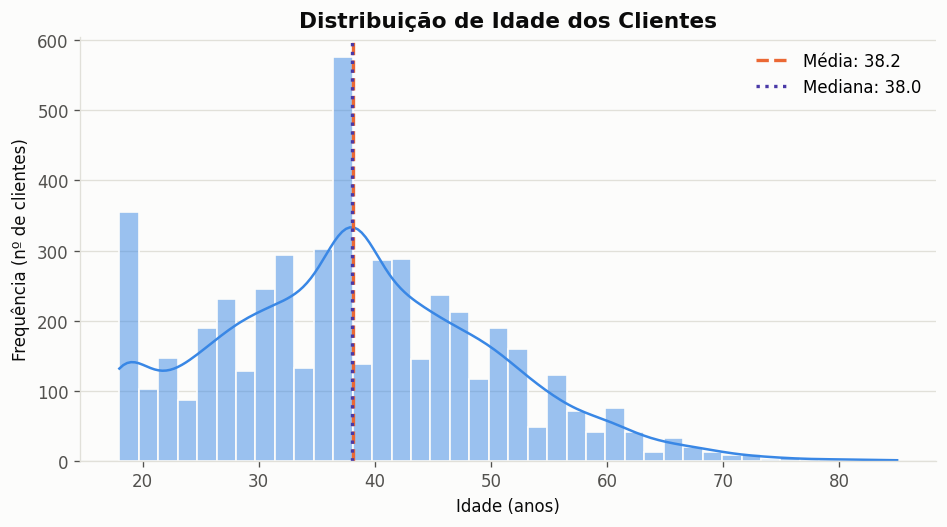

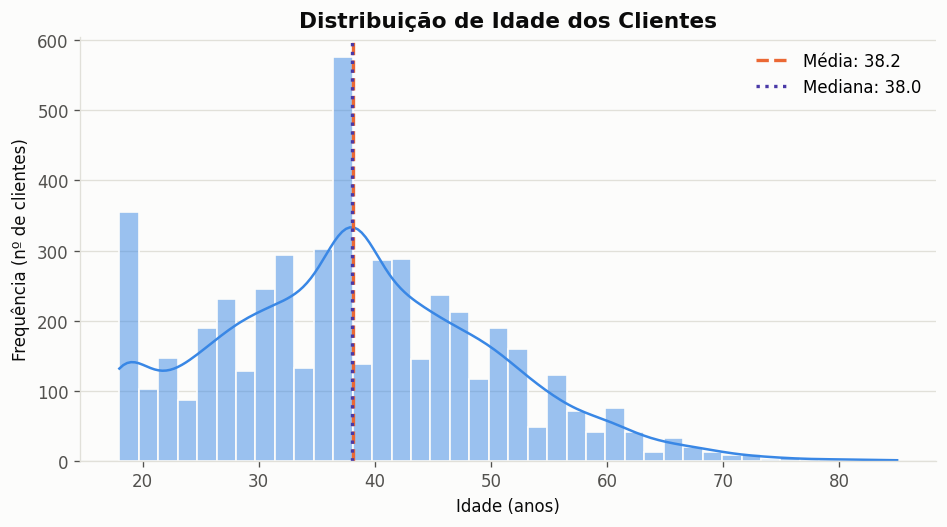

In [4]:
plot_distribution(df, "age", "Distribuição de Idade dos Clientes", "Idade (anos)")


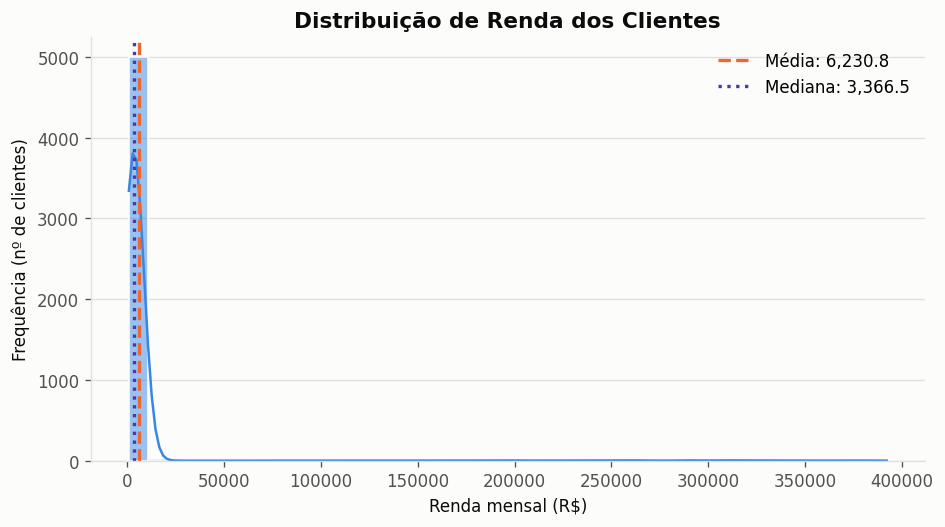

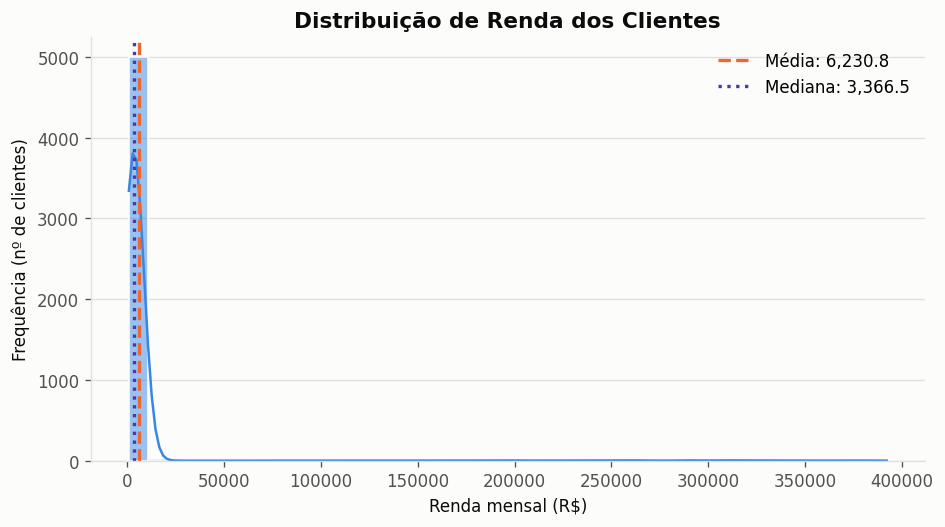

In [5]:
plot_distribution(df, "income", "Distribuição de Renda dos Clientes", "Renda mensal (R$)")


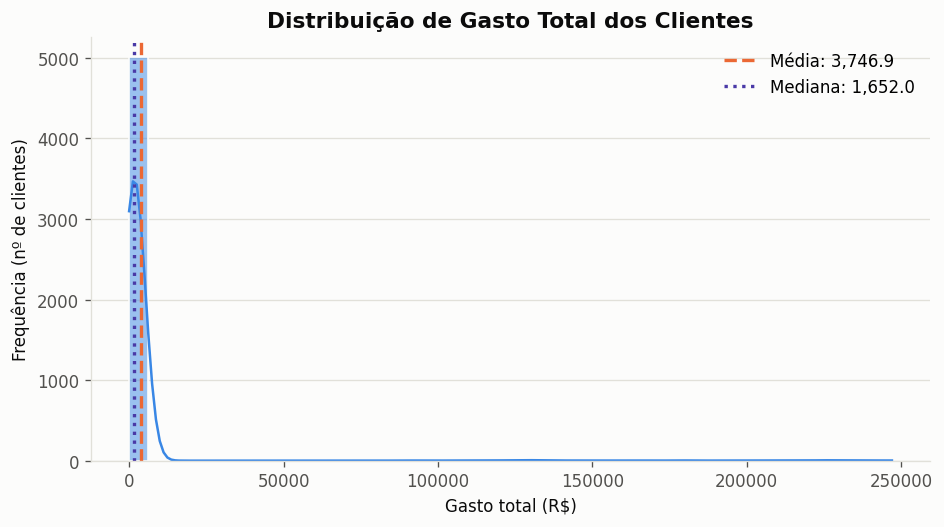

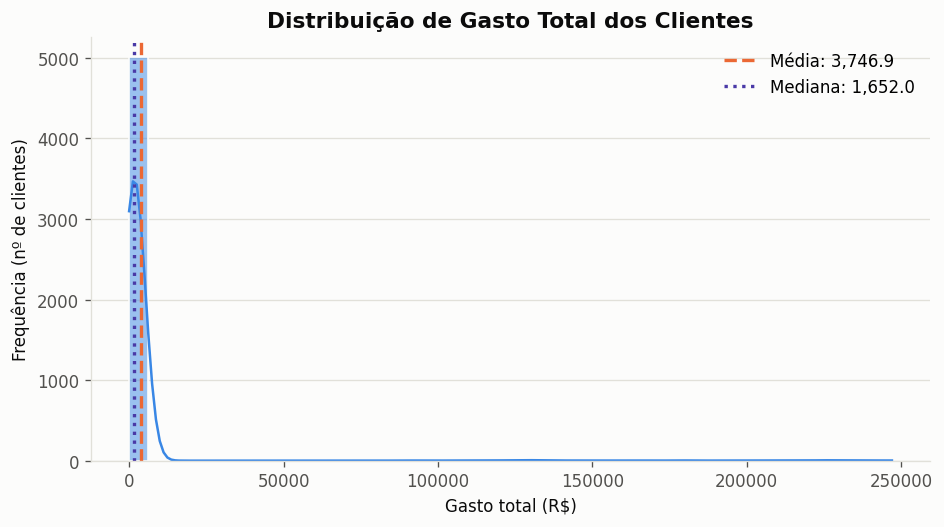

In [6]:
plot_distribution(df, "total_spent", "Distribuição de Gasto Total dos Clientes", "Gasto total (R$)")


As três distribuições confirmam a leitura numérica: `age` tem formato
aproximadamente normal (sininho simétrico), enquanto `income` e `total_spent`
concentram a grande maioria dos clientes em uma faixa baixa, com uma cauda
longa à direita causada pelos outliers.


## Detecção de outliers (método IQR)

Valores abaixo de `Q1 - 1.5*IQR` ou acima de `Q3 + 1.5*IQR` são sinalizados
como outliers — **sem serem removidos**. A decisão de manter, investigar,
corrigir ou transformar é de negócio.


In [7]:
outliers = detect_outliers_iqr(df, COLUNAS_NUMERICAS_PADRAO)
outliers.round(2)


,q1,q3,iqr,lower_bound,upper_bound,total_records,outlier_count,outlier_percentage
column,,,,,,,,
age,30.0,46.00,16.00,6.00,70.00,5070,27,0.53
income,2519.0,4497.75,1978.75,-449.12,7465.88,5070,213,4.20
purchase_count,5.0,9.00,4.00,-1.00,15.00,5070,73,1.44
total_spent,1133.0,2294.75,1161.75,-609.62,4037.38,5070,153,3.02
satisfaction_score,3.5,4.50,1.00,2.00,6.00,5070,14,0.28


In [8]:
for coluna, linha in outliers.iterrows():
    recomendacao = recommend_outlier_action(linha["outlier_percentage"])
    print(f"{coluna} — {linha['outlier_count']} outliers ({linha['outlier_percentage']}%)")
    print(f"  Recomendação: {recomendacao}\n")


age — 27.0 outliers (0.53%)
  Recomendação: Baixa incidência: manter os valores e investigar individualmente (podem ser clientes legítimos de alto valor).

income — 213.0 outliers (4.2%)
  Recomendação: Incidência moderada: investigar a origem (erro de digitação vs. cliente atípico legítimo) antes de decidir entre manter, corrigir ou aplicar transformação (ex.: log) para análises sensíveis a escala.

purchase_count — 73.0 outliers (1.44%)
  Recomendação: Incidência moderada: investigar a origem (erro de digitação vs. cliente atípico legítimo) antes de decidir entre manter, corrigir ou aplicar transformação (ex.: log) para análises sensíveis a escala.

total_spent — 153.0 outliers (3.02%)
  Recomendação: Incidência moderada: investigar a origem (erro de digitação vs. cliente atípico legítimo) antes de decidir entre manter, corrigir ou aplicar transformação (ex.: log) para análises sensíveis a escala.

satisfaction_score — 14.0 outliers (0.28%)
  Recomendação: Baixa incidência: manter os

**Interpretação de negócio:** os outliers de `income` e `total_spent`
representam uma minoria de clientes (poucos %) com valores muito acima do
padrão — plausivelmente clientes corporativos, contas de alto patrimônio, ou
possíveis erros de digitação/duplo lançamento no sistema de origem. Como o
percentual é baixo e cada caso pode ser legítimo, a recomendação é
**investigar individualmente antes de remover** — remover automaticamente
poderia descartar exatamente os clientes de maior valor para o negócio.


## Correlação entre variáveis

Calculamos tanto Pearson (correlação linear) quanto Spearman (correlação por
postos/monotônica), pois — como veremos — os outliers extremos identificados
acima afetam fortemente a correlação linear.


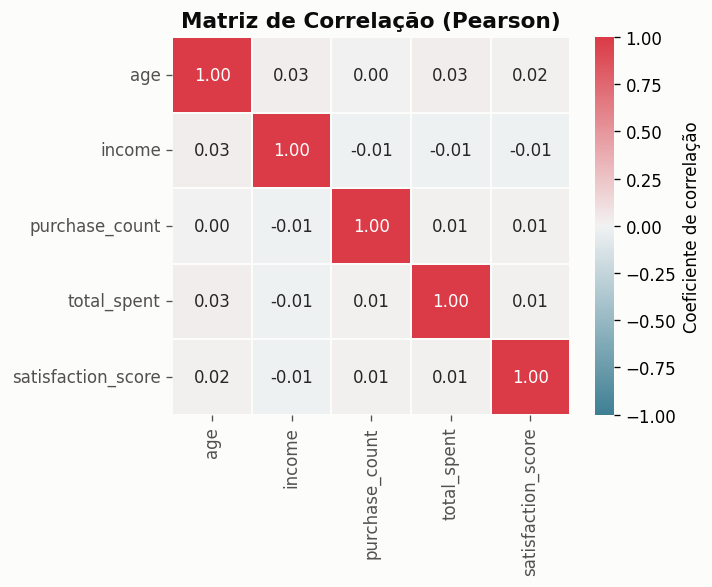

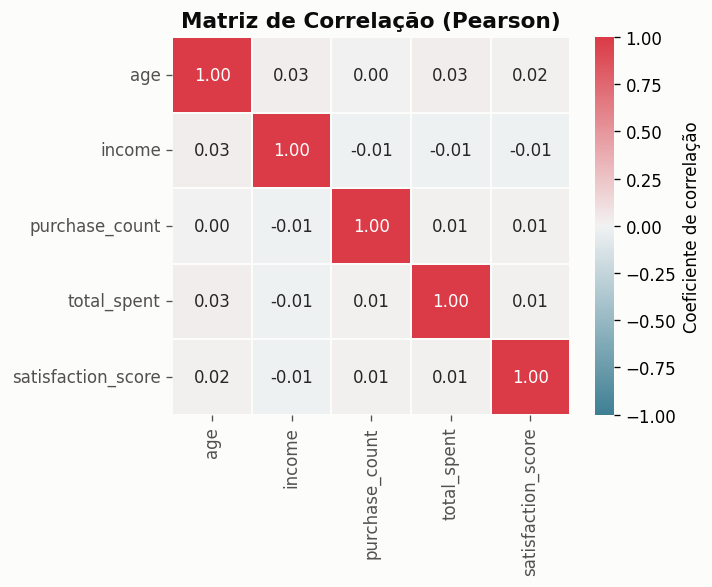

In [9]:
corr_pearson = compute_correlation_matrix(df, COLUNAS_NUMERICAS_PADRAO, method="pearson")
plot_correlation_heatmap(corr_pearson, titulo="Matriz de Correlação (Pearson)")


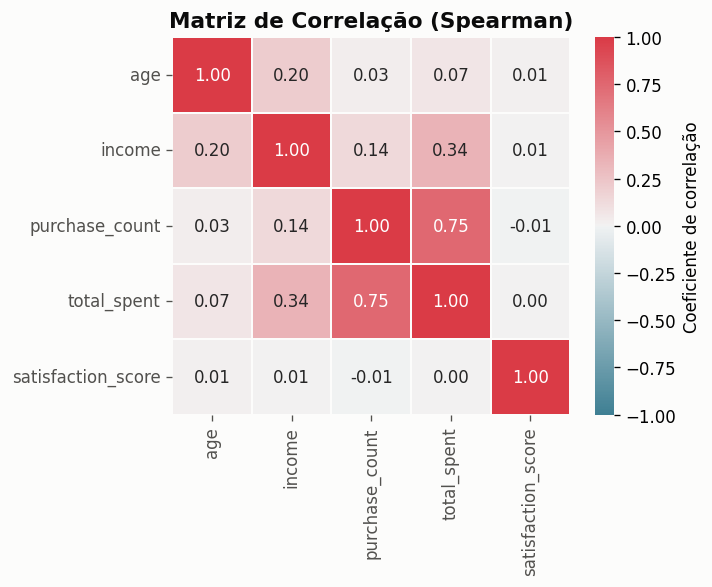

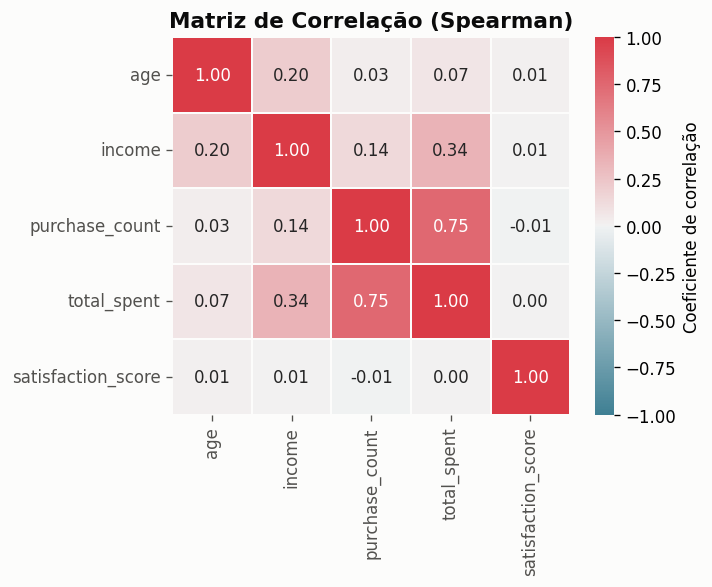

In [10]:
corr_spearman = compute_correlation_matrix(df, COLUNAS_NUMERICAS_PADRAO, method="spearman")
plot_correlation_heatmap(corr_spearman, titulo="Matriz de Correlação (Spearman)")


In [11]:
print("Pares mais correlacionados (Pearson):")
display(top_correlated_pairs(df, COLUNAS_NUMERICAS_PADRAO, method="pearson"))

print("\nPares mais correlacionados (Spearman):")
display(top_correlated_pairs(df, COLUNAS_NUMERICAS_PADRAO, method="spearman"))


Pares mais correlacionados (Pearson):


,variable_1,variable_2,method,correlation
0,age,total_spent,pearson,0.027998
1,age,income,pearson,0.025190
2,age,satisfaction_score,pearson,0.015209
3,purchase_count,satisfaction_score,pearson,0.014823
4,total_spent,satisfaction_score,pearson,0.014001
5,purchase_count,total_spent,pearson,0.011599
6,income,satisfaction_score,pearson,-0.010795
7,income,total_spent,pearson,-0.009461
8,income,purchase_count,pearson,-0.008028
9,age,purchase_count,pearson,0.004271



Pares mais correlacionados (Spearman):


,variable_1,variable_2,method,correlation
0,purchase_count,total_spent,spearman,0.747806
1,income,total_spent,spearman,0.341267
2,age,income,spearman,0.204725
3,income,purchase_count,spearman,0.139394
4,age,total_spent,spearman,0.068116
5,age,purchase_count,spearman,0.027178
6,age,satisfaction_score,spearman,0.009333
7,income,satisfaction_score,spearman,0.006125
8,purchase_count,satisfaction_score,spearman,-0.005607
9,total_spent,satisfaction_score,spearman,0.001321


**Achado central deste notebook:** a correlação de **Pearson** entre `income`
e `total_spent` é próxima de zero, o que pareceria indicar "renda não
influencia gasto" — uma conclusão contra-intuitiva. Mas a correlação de
**Spearman** entre as mesmas variáveis é bem mais alta e estatisticamente
significativa (ver teste formal no notebook 04). A explicação: os outliers
extremos e *independentes* injetados em `income` e `total_spent` (poucos
clientes com valores absurdamente altos em uma variável, mas não
necessariamente na outra) distorcem a covariância usada por Pearson, que é
sensível a valores extremos. Spearman, por trabalhar com postos (rankings),
é robusto a essa distorção e revela a relação monotônica real que existe
entre as variáveis para a maioria dos clientes.

**Lição prática:** nunca reporte apenas Pearson em dados de negócio com
potencial de outliers — sempre calcule Spearman como verificação cruzada.

Lembrando sempre: **correlação não implica causalidade**.


## Prévia: comparação entre segmentos de clientes

Os segmentos (`Low / Medium / High Value`, criados no notebook 02 a partir
dos tercis de `total_spent`) serão explorados em profundidade no notebook 04,
mas uma primeira visão já é útil aqui:


In [12]:
summarize_segments(df)


age                income               purchase_count              satisfaction_score               \
                   mean median count     mean  median count           mean median count               mean median count   
customer_segment                                                                                                          
Low Value         37.52   38.0  1690  6437.84  2879.0  1690           8.67    5.0  1690               3.97    4.0  1690   
Medium Value      37.63   38.0  1692  5528.42  3357.5  1692          11.45    7.0  1692               3.96    4.0  1692   
High Value        39.35   38.0  1688  6727.69  4028.0  1688          14.79    9.0  1688               3.96    4.0  1688   

                 total_spent                
                        mean  median count  
customer_segment                            
Low Value             905.65   945.0  1690  
Medium Value         1657.70  1652.5  1692  
High Value           8685.75  2643.0  1688